# NJN_BestModel_FullPack_EffNet_Full_vs_PCAHybrid_V3

This notebook is a stricter V3 evaluation/development pack for the two proposed EfficientNet-based models:

1. **Hybrid Fusion (Final)** = EfficientNetB0 embeddings + biomedical color biomarkers + SVM (RBF)  
2. **PCA-Hybrid** = PCA-compressed EfficientNetB0 embeddings + biomedical color biomarkers + SVM (RBF)

### What is improved in V3
- **Same test split** for both proposed models
- **Exact 95% CI (AUC)** by bootstrap
- **Exact 95% CI (Brier)** by bootstrap
- **Tight classical ROI + wider deep ROI** strategy
- **Train-only imputer + train-only PCA**
- **Side-by-side annotated panels**
- **Histogram panel with bootstrap CI**
- **Confusion Matrix (Full vs PCA) + Threshold Summary Panel**
- **All-model statistical validation figure with annotated AUC and CI**
- **Development bundle export** for future deployment

In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm tensorflow joblib

In [2]:
import os, glob, random, json, joblib, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix,
    brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from google.colab import drive

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Random seed set to:", SEED)

TensorFlow version: 2.20.0
Random seed set to: 42


In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
DATASET_PATH = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
all_imgs = []

for ext in img_exts:
    all_imgs += glob.glob(os.path.join(DATASET_PATH, "**", ext), recursive=True)

print("Total images found:", len(all_imgs))
print("Sample paths:", all_imgs[:5])

Total images found: 760
Sample paths: ['/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1024).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (566).jpg']


In [7]:
def infer_label_from_path(p):
    lp = p.lower()

    pos_keys = ["jaundice", "icteric", "positive", "pos", "case", "patient", "affected", "yellow"]
    neg_keys = ["normal", "control", "negative", "neg", "healthy", "non"]

    if any(k in lp for k in pos_keys):
        return 1
    if any(k in lp for k in neg_keys):
        return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p, l) for p, l in pairs if l is not None]

imgs = [p for p, l in pairs]
y_all = np.array([l for p, l in pairs])

print("Total labeled:", len(pairs))
print("Class counts (0=Normal, 1=Jaundice):", np.bincount(y_all))
print("Example pairs:", pairs[:3])

Total labeled: 760
Class counts (0=Normal, 1=Jaundice): [560 200]
Example pairs: [('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', 0)]


## ROI strategy in V3

### Classical branch
Uses the **tight / biomarker-focused ROIs**.

### Deep branch
Uses **wider context ROIs**, so the CNN can benefit from more anatomical context.

In [8]:
# =========================================
# Classical ROI branch (tight final version)
# =========================================
def get_forehead_box_classical(img_bgr):
    h, w = img_bgr.shape[:2]

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    candidates = []
    min_area = max(300, int(0.002 * h * w))
    for i in range(1, num_labels):
        x, y, bw, bh, area = stats[i]
        if area >= min_area:
            candidates.append((i, x, y, bw, bh, area))

    if candidates:
        candidates = sorted(candidates, key=lambda t: (t[2], -t[5]))
        _, x, y, bw, bh, _ = candidates[0]

        pad_x = int(0.05 * bw)
        pad_y = int(0.05 * bh)
        x = max(0, x - pad_x)
        y = max(0, y - pad_y)
        bw = min(w - x, bw + 2 * pad_x)
        bh = min(h - y, bh + 2 * pad_y)

        x1 = max(0, x + int(0.28 * bw))
        x2 = min(w, x + int(0.68 * bw))
        y1 = max(0, y + int(0.05 * bh))
        y2 = min(h, y + int(0.15 * bh))
    else:
        x1 = int(0.34 * w)
        x2 = int(0.60 * w)
        y1 = int(0.08 * h)
        y2 = int(0.15 * h)

    if (x2 - x1) < 12 or (y2 - y1) < 12:
        x1 = int(0.34 * w)
        x2 = int(0.60 * w)
        y1 = int(0.08 * h)
        y2 = int(0.15 * h)

    return x1, y1, x2, y2


def extract_forehead_roi_classical(img_bgr):
    x1, y1, x2, y2 = get_forehead_box_classical(img_bgr)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


def extract_chest_roi_classical(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.28 * w)
    x2 = int(0.78 * w)
    y1 = int(0.50 * h)
    y2 = int(0.72 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


def extract_abdomen_roi_classical(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.60 * h)
    y2 = int(0.92 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

In [9]:
# =========================================
# Deep ROI branch (wider context version)
# =========================================
def extract_forehead_roi_deep(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.10 * h)
    y2 = int(0.40 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


def extract_chest_roi_deep(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.40 * h)
    y2 = int(0.80 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


def extract_abdomen_roi_deep(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.55 * h)
    y2 = int(0.92 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

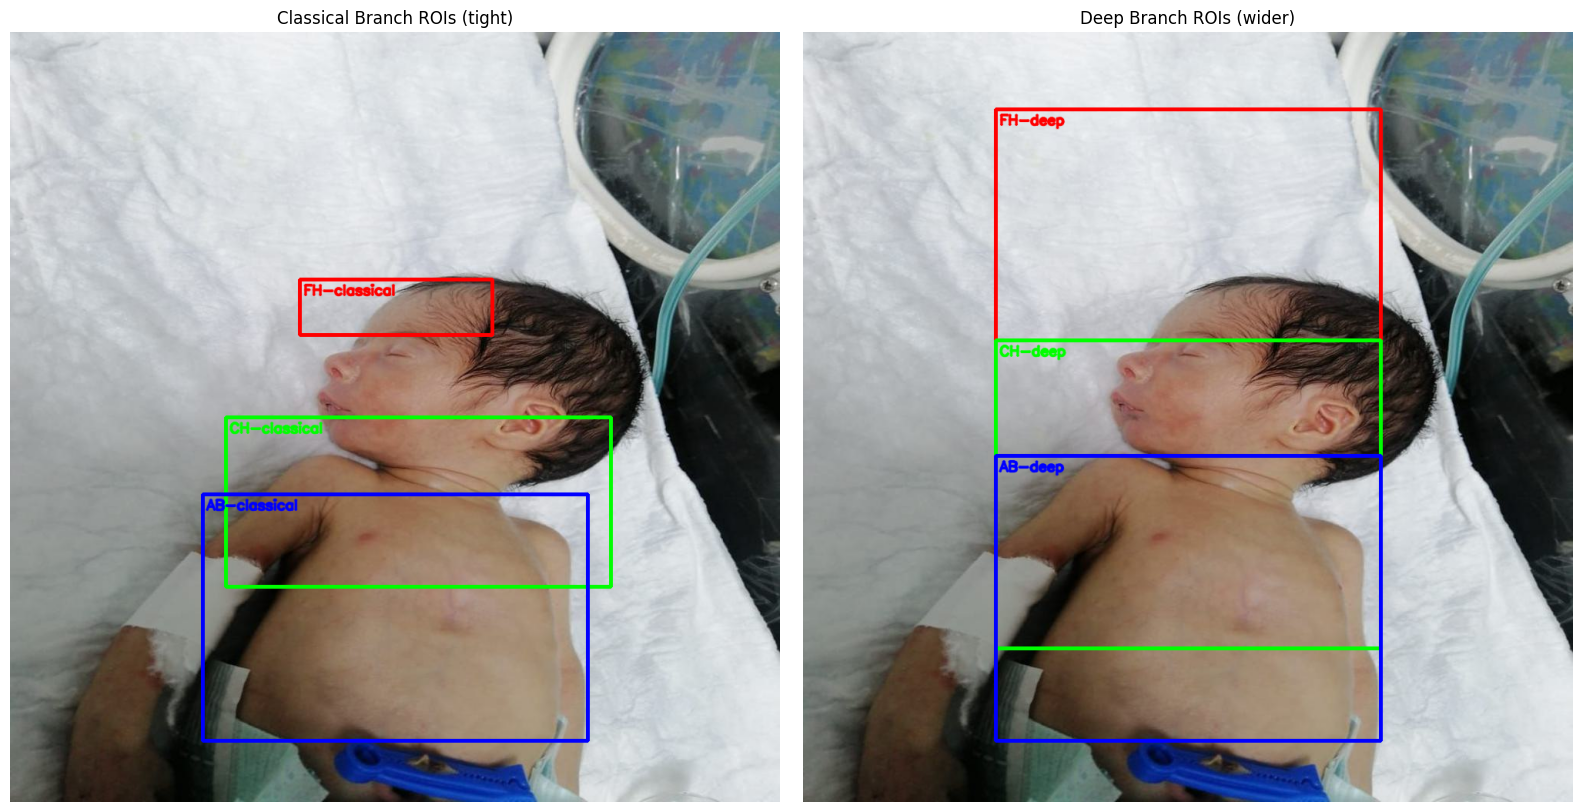

In [10]:
sample_path = imgs[0]
img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

vis_classical = img_rgb.copy()
x1f, y1f, x2f, y2f = get_forehead_box_classical(img)
cv2.rectangle(vis_classical, (x1f, y1f), (x2f, y2f), (255, 0, 0), 3)
cv2.putText(vis_classical, "FH-classical", (x1f + 5, max(20, y1f + 20)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2, cv2.LINE_AA)

x1c, x2c = int(0.28 * w), int(0.78 * w)
y1c, y2c = int(0.50 * h), int(0.72 * h)
cv2.rectangle(vis_classical, (x1c, y1c), (x2c, y2c), (0, 255, 0), 3)
cv2.putText(vis_classical, "CH-classical", (x1c + 5, y1c + 20),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

x1a, x2a = int(0.25 * w), int(0.75 * w)
y1a, y2a = int(0.60 * h), int(0.92 * h)
cv2.rectangle(vis_classical, (x1a, y1a), (x2a, y2a), (0, 0, 255), 3)
cv2.putText(vis_classical, "AB-classical", (x1a + 5, y1a + 20),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)

vis_deep = img_rgb.copy()
x1fd, x2fd = int(0.25 * w), int(0.75 * w)
y1fd, y2fd = int(0.10 * h), int(0.40 * h)
cv2.rectangle(vis_deep, (x1fd, y1fd), (x2fd, y2fd), (255, 0, 0), 3)
cv2.putText(vis_deep, "FH-deep", (x1fd + 5, y1fd + 20),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2, cv2.LINE_AA)

x1cd, x2cd = int(0.25 * w), int(0.75 * w)
y1cd, y2cd = int(0.40 * h), int(0.80 * h)
cv2.rectangle(vis_deep, (x1cd, y1cd), (x2cd, y2cd), (0, 255, 0), 3)
cv2.putText(vis_deep, "CH-deep", (x1cd + 5, y1cd + 20),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

x1ad, x2ad = int(0.25 * w), int(0.75 * w)
y1ad, y2ad = int(0.55 * h), int(0.92 * h)
cv2.rectangle(vis_deep, (x1ad, y1ad), (x2ad, y2ad), (0, 0, 255), 3)
cv2.putText(vis_deep, "AB-deep", (x1ad + 5, y1ad + 20),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(vis_classical)
plt.title("Classical Branch ROIs (tight)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(vis_deep)
plt.title("Deep Branch ROIs (wider)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)

    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0

    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))

    out = cv2.merge([b, g, r])
    return np.clip(out, 0, 255).astype(np.uint8)


def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    L2 = clahe.apply(L)

    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)


def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr


def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)

    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)

    return mask


def masked_stats(channel, mask):
    vals = channel[mask == 255].astype(np.float32)

    if vals.size < 30:
        return (np.nan,) * 6

    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )


def extract_classical_features(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)

    if np.sum(mask == 255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8) * 255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:, :, 0]
    G = roi_rgb[:, :, 1]
    B = roi_rgb[:, :, 2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))
    rg_balance = float((Rm - Gm) / (Rm + Gm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom)
    g_ch = float(Gm / denom)
    b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask == 255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0, 180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:, :, 0]
    a = lab[:, :, 1]
    b = lab[:, :, 2]

    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask == 255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "RG_balance": rg_balance,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }

    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

In [12]:
IMG_SIZE = 224

eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
eff.trainable = False


def roi_to_tensor(roi_bgr):
    roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    roi = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    x = roi.astype(np.float32)
    x = preprocess_input(x)
    return x


def get_eff_embedding(img_bgr, roi_fn):
    roi = roi_fn(img_bgr)
    if roi is None:
        return None

    x = roi_to_tensor(roi)
    emb = eff(np.expand_dims(x, 0), training=False).numpy().ravel()
    return emb

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
rows = []
FH_list, CH_list, AB_list = [], [], []
failed = 0

for p, label in tqdm(pairs, desc="Building EffNet Full-vs-PCAHybrid V3 dataset"):
    img = cv2.imread(p)

    if img is None:
        failed += 1
        continue

    fh_c = extract_forehead_roi_classical(img)
    ch_c = extract_chest_roi_classical(img)
    ab_c = extract_abdomen_roi_classical(img)

    e_fh = get_eff_embedding(img, extract_forehead_roi_deep)
    e_ch = get_eff_embedding(img, extract_chest_roi_deep)
    e_ab = get_eff_embedding(img, extract_abdomen_roi_deep)

    if fh_c is None or ch_c is None or ab_c is None:
        failed += 1
        continue

    if (e_fh is None) or (e_ch is None) or (e_ab is None):
        failed += 1
        continue

    try:
        fh_feat = extract_classical_features(fh_c)
        ch_feat = extract_classical_features(ch_c)
        ab_feat = extract_classical_features(ab_c)
    except:
        failed += 1
        continue

    row = {"path": p, "label": int(label)}
    row.update({f"FH_{k}": v for k, v in fh_feat.items()})
    row.update({f"CH_{k}": v for k, v in ch_feat.items()})
    row.update({f"AB_{k}": v for k, v in ab_feat.items()})

    rows.append(row)
    FH_list.append(e_fh)
    CH_list.append(e_ch)
    AB_list.append(e_ab)

X_classical_df = pd.DataFrame(rows)
FH_mat = np.vstack(FH_list)
CH_mat = np.vstack(CH_list)
AB_mat = np.vstack(AB_list)

print("Classical DF:", X_classical_df.shape, "Failed:", failed)
print("Embeddings:", FH_mat.shape, CH_mat.shape, AB_mat.shape)
print("Label counts:\n", X_classical_df["label"].value_counts())

Building EffNet Full-vs-PCAHybrid V3 dataset: 100%|██████████| 760/760 [22:09<00:00,  1.75s/it]

Classical DF: (760, 83) Failed: 0
Embeddings: (760, 1280) (760, 1280) (760, 1280)
Label counts:
 label
0    560
1    200
Name: count, dtype: int64


In [23]:
y = X_classical_df["label"].astype(int).values
idx_all = np.arange(len(y))

train_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train = y[train_idx]
y_test = y[test_idx]

print("Train/Test:", len(train_idx), len(test_idx))
print("Test distribution:", np.bincount(y_test))

Train/Test: 608 152
Test distribution: [112  40]


In [24]:
classical_cols = [c for c in X_classical_df.columns if c not in ["path", "label"]]

Xc_train_df = X_classical_df.iloc[train_idx][classical_cols]
Xc_test_df = X_classical_df.iloc[test_idx][classical_cols]

imputer = SimpleImputer(strategy="median")
Xc_train = imputer.fit_transform(Xc_train_df)
Xc_test = imputer.transform(Xc_test_df)

deep_all = np.hstack([FH_mat, CH_mat, AB_mat])  # (N, 3840)
deep_train = deep_all[train_idx]
deep_test = deep_all[test_idx]

X_full_train = np.hstack([Xc_train, deep_train])
X_full_test = np.hstack([Xc_test, deep_test])

print("X_full_train:", X_full_train.shape)
print("X_full_test :", X_full_test.shape)

X_full_train: (608, 3921)
X_full_test : (152, 3921)


In [25]:
def make_svm_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dims = [64, 96, 128, 160, 192, 256, 320]
sweep_rows = []

for d in dims:
    pca_tmp = PCA(n_components=d, random_state=42)
    deep_train_pca_tmp = pca_tmp.fit_transform(deep_train)

    X_train_tmp = np.hstack([Xc_train, deep_train_pca_tmp])

    svm_tmp = make_svm_pipeline()
    cv_auc = cross_val_score(svm_tmp, X_train_tmp, y_train, cv=cv, scoring="roc_auc")

    sweep_rows.append({
        "pca_dim": d,
        "explained_var_sum": float(pca_tmp.explained_variance_ratio_.sum()),
        "cv_auc_mean": float(cv_auc.mean())
    })

    print(f"PCA={d} | Explained={pca_tmp.explained_variance_ratio_.sum():.3f} | CV AUC={cv_auc.mean():.4f}")

sweep_df = pd.DataFrame(sweep_rows).sort_values("cv_auc_mean", ascending=False).reset_index(drop=True)
best_dim = int(sweep_df.iloc[0]["pca_dim"])

print("\nBest PCA dim selected from training only:", best_dim)
sweep_df

PCA=64 | Explained=0.603 | CV AUC=0.8736
PCA=96 | Explained=0.683 | CV AUC=0.8724
PCA=128 | Explained=0.742 | CV AUC=0.8742
PCA=160 | Explained=0.787 | CV AUC=0.8762
PCA=192 | Explained=0.822 | CV AUC=0.8665
PCA=256 | Explained=0.877 | CV AUC=0.8535
PCA=320 | Explained=0.916 | CV AUC=0.8383

Best PCA dim selected from training only: 160


,pca_dim,explained_var_sum,cv_auc_mean
0,160,0.786554,0.876159
1,128,0.741600,0.874189
2,64,0.602825,0.873551
3,96,0.683232,0.872374
4,192,0.822296,0.866526
5,256,0.876782,0.853538
6,320,0.915961,0.838329


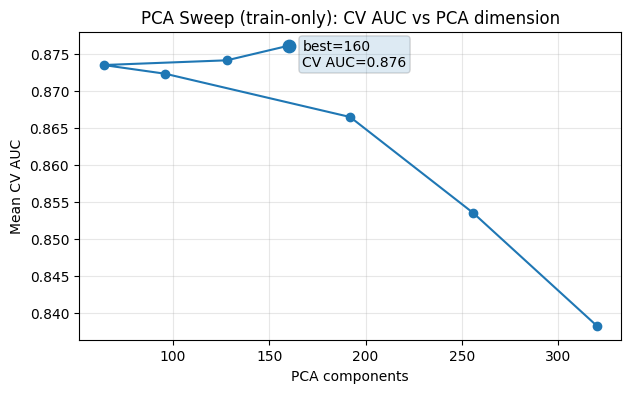

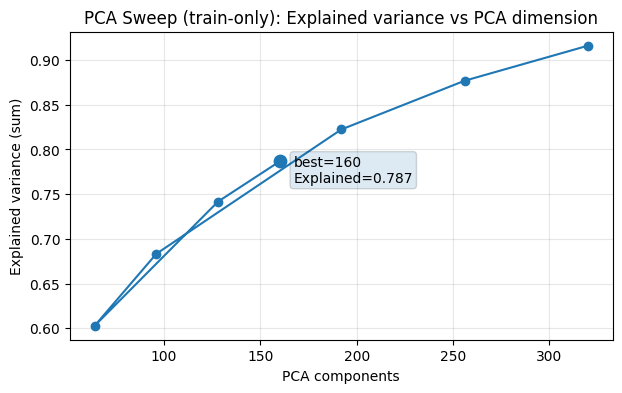

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(sweep_df["pca_dim"], sweep_df["cv_auc_mean"], marker="o")
best_row = sweep_df.iloc[0]
plt.scatter([best_row["pca_dim"]], [best_row["cv_auc_mean"]], s=80)
plt.annotate(
    f'best={int(best_row["pca_dim"])}\nCV AUC={best_row["cv_auc_mean"]:.3f}',
    (best_row["pca_dim"], best_row["cv_auc_mean"]),
    textcoords="offset points",
    xytext=(10, -15),
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
)
plt.xlabel("PCA components")
plt.ylabel("Mean CV AUC")
plt.title("PCA Sweep (train-only): CV AUC vs PCA dimension")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(sweep_df["pca_dim"], sweep_df["explained_var_sum"], marker="o")
best_row = sweep_df[sweep_df["pca_dim"] == best_dim].iloc[0]
plt.scatter([best_row["pca_dim"]], [best_row["explained_var_sum"]], s=80)
plt.annotate(
    f'best={int(best_row["pca_dim"])}\nExplained={best_row["explained_var_sum"]:.3f}',
    (best_row["pca_dim"], best_row["explained_var_sum"]),
    textcoords="offset points",
    xytext=(10, -15),
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
)
plt.xlabel("PCA components")
plt.ylabel("Explained variance (sum)")
plt.title("PCA Sweep (train-only): Explained variance vs PCA dimension")
plt.grid(alpha=0.3)
plt.show()

In [27]:
pca = PCA(n_components=best_dim, random_state=42)
deep_train_pca = pca.fit_transform(deep_train)
deep_test_pca = pca.transform(deep_test)

X_pca_train = np.hstack([Xc_train, deep_train_pca])
X_pca_test = np.hstack([Xc_test, deep_test_pca])

print("X_pca_train:", X_pca_train.shape)
print("X_pca_test :", X_pca_test.shape)
print("Best PCA explained variance sum:", pca.explained_variance_ratio_.sum())

X_pca_train: (608, 241)
X_pca_test : (152, 241)
Best PCA explained variance sum: 0.78655434


In [28]:
svm_full = make_svm_pipeline()
svm_pca = make_svm_pipeline()

svm_full.fit(X_full_train, y_train)
svm_pca.fit(X_pca_train, y_train)

prob_full = svm_full.predict_proba(X_full_test)[:, 1]
prob_pca = svm_pca.predict_proba(X_pca_test)[:, 1]

print("Full Hybrid Test AUC:", roc_auc_score(y_test, prob_full))
print("PCA-Hybrid Test AUC :", roc_auc_score(y_test, prob_pca))

Full Hybrid Test AUC: 0.9265625
PCA-Hybrid Test AUC : 0.8997767857142858


In [29]:
def bootstrap_auc_ci(y_true, prob, n_boot=2000, seed=42, desc="Bootstrap AUC"):
    rng = np.random.RandomState(seed)
    boot = []

    y_true = np.array(y_true)
    prob = np.array(prob)

    for _ in tqdm(range(n_boot), desc=desc):
        idx = rng.randint(0, len(prob), len(prob))
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot.append(roc_auc_score(y_true[idx], prob[idx]))

    boot = np.array(boot)
    low = np.percentile(boot, 2.5)
    high = np.percentile(boot, 97.5)
    return float(low), float(high), boot


def bootstrap_brier_ci(y_true, prob, n_boot=2000, seed=42, desc="Bootstrap Brier"):
    rng = np.random.RandomState(seed)
    boot = []

    y_true = np.array(y_true)
    prob = np.array(prob)

    for _ in tqdm(range(n_boot), desc=desc):
        idx = rng.randint(0, len(prob), len(prob))
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot.append(brier_score_loss(y_true[idx], prob[idx]))

    boot = np.array(boot)
    low = np.percentile(boot, 2.5)
    high = np.percentile(boot, 97.5)
    return float(low), float(high), boot


def evaluate_model(y_true, prob, title="Model", n_boot=2000, seed=42):
    y_true = np.array(y_true)
    prob = np.array(prob)

    fpr, tpr, thr = roc_curve(y_true, prob)
    rocA = auc(fpr, tpr)

    prec_curve, rec_curve, _ = precision_recall_curve(y_true, prob)
    ap = average_precision_score(y_true, prob)

    brier = brier_score_loss(y_true, prob)
    frac_pos, mean_pred = calibration_curve(y_true, prob, n_bins=10)

    j = tpr - fpr
    idx = np.argmax(j)
    youden_thr = thr[idx]

    pred_y = (prob >= youden_thr).astype(int)
    cm = confusion_matrix(y_true, pred_y)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_true, pred_y)
    prec = precision_score(y_true, pred_y, zero_division=0)
    rec = recall_score(y_true, pred_y, zero_division=0)
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, pred_y, zero_division=0)

    auc_low, auc_high, boot_auc = bootstrap_auc_ci(
        y_true, prob, n_boot=n_boot, seed=seed, desc=f"Bootstrap AUC — {title}"
    )
    brier_low, brier_high, boot_brier = bootstrap_brier_ci(
        y_true, prob, n_boot=n_boot, seed=seed, desc=f"Bootstrap Brier — {title}"
    )

    return {
        "title": title,
        "fpr": fpr,
        "tpr": tpr,
        "thr": thr,
        "roc_auc": float(rocA),
        "prec_curve": prec_curve,
        "rec_curve": rec_curve,
        "ap": float(ap),
        "brier": float(brier),
        "frac_pos": frac_pos,
        "mean_pred": mean_pred,
        "youden_thr": float(youden_thr),
        "youden_idx": int(idx),
        "acc": float(acc),
        "prec": float(prec),
        "rec": float(rec),
        "spec": float(spec),
        "f1": float(f1),
        "cm": [[int(tn), int(fp)], [int(fn), int(tp)]],
        "auc_ci_low": float(auc_low),
        "auc_ci_high": float(auc_high),
        "brier_ci_low": float(brier_low),
        "brier_ci_high": float(brier_high),
        "boot_auc": boot_auc,
        "boot_brier": boot_brier,
        "prob": prob,
        "y_true": y_true
    }

In [30]:
res_full = evaluate_model(
    y_test, prob_full,
    title="Hybrid Fusion (Final)",
    n_boot=2000,
    seed=42
)

res_pca = evaluate_model(
    y_test, prob_pca,
    title=f"PCA-Hybrid ({best_dim})",
    n_boot=2000,
    seed=42
)

print("Hybrid Fusion (Final):", {
    "AUC": res_full["roc_auc"],
    "AUC_CI": [res_full["auc_ci_low"], res_full["auc_ci_high"]],
    "Brier": res_full["brier"],
    "Brier_CI": [res_full["brier_ci_low"], res_full["brier_ci_high"]]
})
print("PCA-Hybrid:", {
    "AUC": res_pca["roc_auc"],
    "AUC_CI": [res_pca["auc_ci_low"], res_pca["auc_ci_high"]],
    "Brier": res_pca["brier"],
    "Brier_CI": [res_pca["brier_ci_low"], res_pca["brier_ci_high"]]
})

Bootstrap Brier — PCA-Hybrid (160): 100%|██████████| 2000/2000 [00:00<00:00, 2219.96it/s]

Hybrid Fusion (Final): {'AUC': 0.9265625, 'AUC_CI': [0.8729145884498788, 0.9707166431913674], 'Brier': 0.07902956668750619, 'Brier_CI': [0.051968999415474074, 0.10969041934460427]}
PCA-Hybrid: {'AUC': 0.8997767857142858, 'AUC_CI': [0.8373737225013311, 0.9514071085164836], 'Brier': 0.10181082915462293, 'Brier_CI': [0.06999051663307766, 0.13581666821700186]}


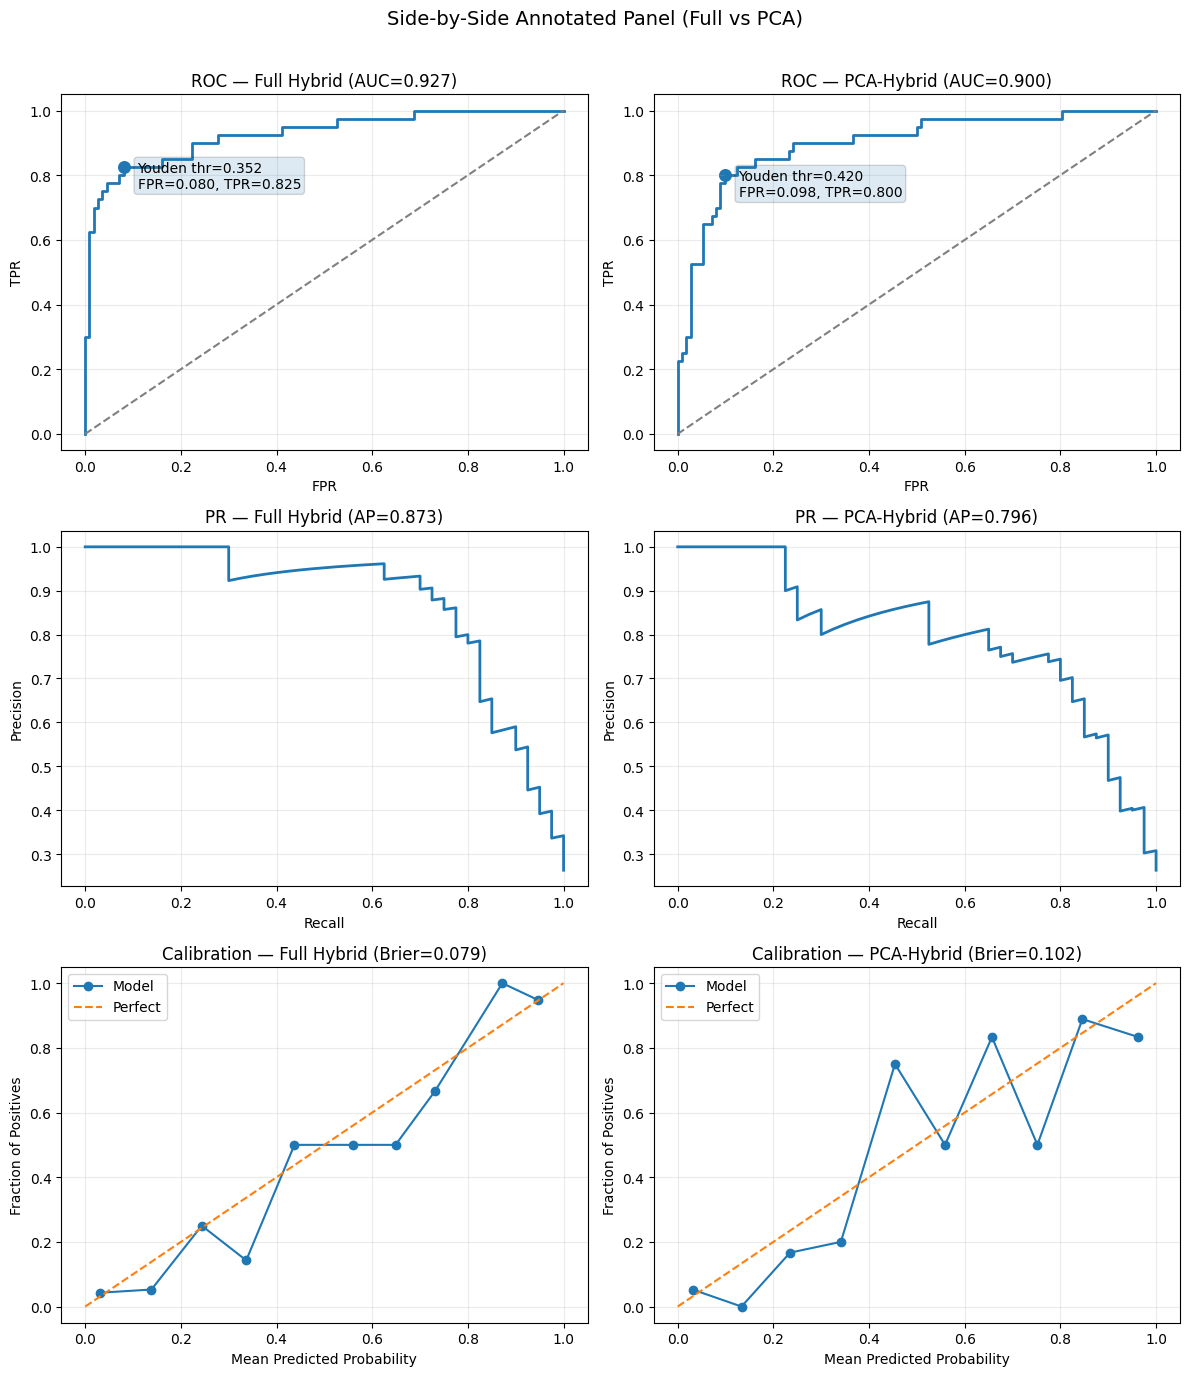

In [31]:
def plot_side_by_side_annotated_panel(res_full, res_pca):
    fig, ax = plt.subplots(3, 2, figsize=(12, 14))
    fig.suptitle("Side-by-Side Annotated Panel (Full vs PCA)", fontsize=14)

    iF = res_full["youden_idx"]
    ax[0, 0].plot(res_full["fpr"], res_full["tpr"], linewidth=2)
    ax[0, 0].plot([0, 1], [0, 1], '--', color='gray')
    ax[0, 0].scatter([res_full["fpr"][iF]], [res_full["tpr"][iF]], s=70)
    ax[0, 0].annotate(
        f"Youden thr={res_full['youden_thr']:.3f}\nFPR={res_full['fpr'][iF]:.3f}, TPR={res_full['tpr'][iF]:.3f}",
        (res_full["fpr"][iF], res_full["tpr"][iF]),
        textcoords="offset points", xytext=(10, -15),
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
    )
    ax[0, 0].set_title(f"ROC — Full Hybrid (AUC={res_full['roc_auc']:.3f})")
    ax[0, 0].set_xlabel("FPR")
    ax[0, 0].set_ylabel("TPR")
    ax[0, 0].grid(alpha=0.25)

    iP = res_pca["youden_idx"]
    ax[0, 1].plot(res_pca["fpr"], res_pca["tpr"], linewidth=2)
    ax[0, 1].plot([0, 1], [0, 1], '--', color='gray')
    ax[0, 1].scatter([res_pca["fpr"][iP]], [res_pca["tpr"][iP]], s=70)
    ax[0, 1].annotate(
        f"Youden thr={res_pca['youden_thr']:.3f}\nFPR={res_pca['fpr'][iP]:.3f}, TPR={res_pca['tpr'][iP]:.3f}",
        (res_pca["fpr"][iP], res_pca["tpr"][iP]),
        textcoords="offset points", xytext=(10, -15),
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
    )
    ax[0, 1].set_title(f"ROC — PCA-Hybrid (AUC={res_pca['roc_auc']:.3f})")
    ax[0, 1].set_xlabel("FPR")
    ax[0, 1].set_ylabel("TPR")
    ax[0, 1].grid(alpha=0.25)

    ax[1, 0].plot(res_full["rec_curve"], res_full["prec_curve"], linewidth=2)
    ax[1, 0].set_title(f"PR — Full Hybrid (AP={res_full['ap']:.3f})")
    ax[1, 0].set_xlabel("Recall")
    ax[1, 0].set_ylabel("Precision")
    ax[1, 0].grid(alpha=0.25)

    ax[1, 1].plot(res_pca["rec_curve"], res_pca["prec_curve"], linewidth=2)
    ax[1, 1].set_title(f"PR — PCA-Hybrid (AP={res_pca['ap']:.3f})")
    ax[1, 1].set_xlabel("Recall")
    ax[1, 1].set_ylabel("Precision")
    ax[1, 1].grid(alpha=0.25)

    ax[2, 0].plot(res_full["mean_pred"], res_full["frac_pos"], "o-", label="Model")
    ax[2, 0].plot([0, 1], [0, 1], "--", label="Perfect")
    ax[2, 0].set_title(f"Calibration — Full Hybrid (Brier={res_full['brier']:.3f})")
    ax[2, 0].set_xlabel("Mean Predicted Probability")
    ax[2, 0].set_ylabel("Fraction of Positives")
    ax[2, 0].legend()
    ax[2, 0].grid(alpha=0.25)

    ax[2, 1].plot(res_pca["mean_pred"], res_pca["frac_pos"], "o-", label="Model")
    ax[2, 1].plot([0, 1], [0, 1], "--", label="Perfect")
    ax[2, 1].set_title(f"Calibration — PCA-Hybrid (Brier={res_pca['brier']:.3f})")
    ax[2, 1].set_xlabel("Mean Predicted Probability")
    ax[2, 1].set_ylabel("Fraction of Positives")
    ax[2, 1].legend()
    ax[2, 1].grid(alpha=0.25)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_side_by_side_annotated_panel(res_full, res_pca)

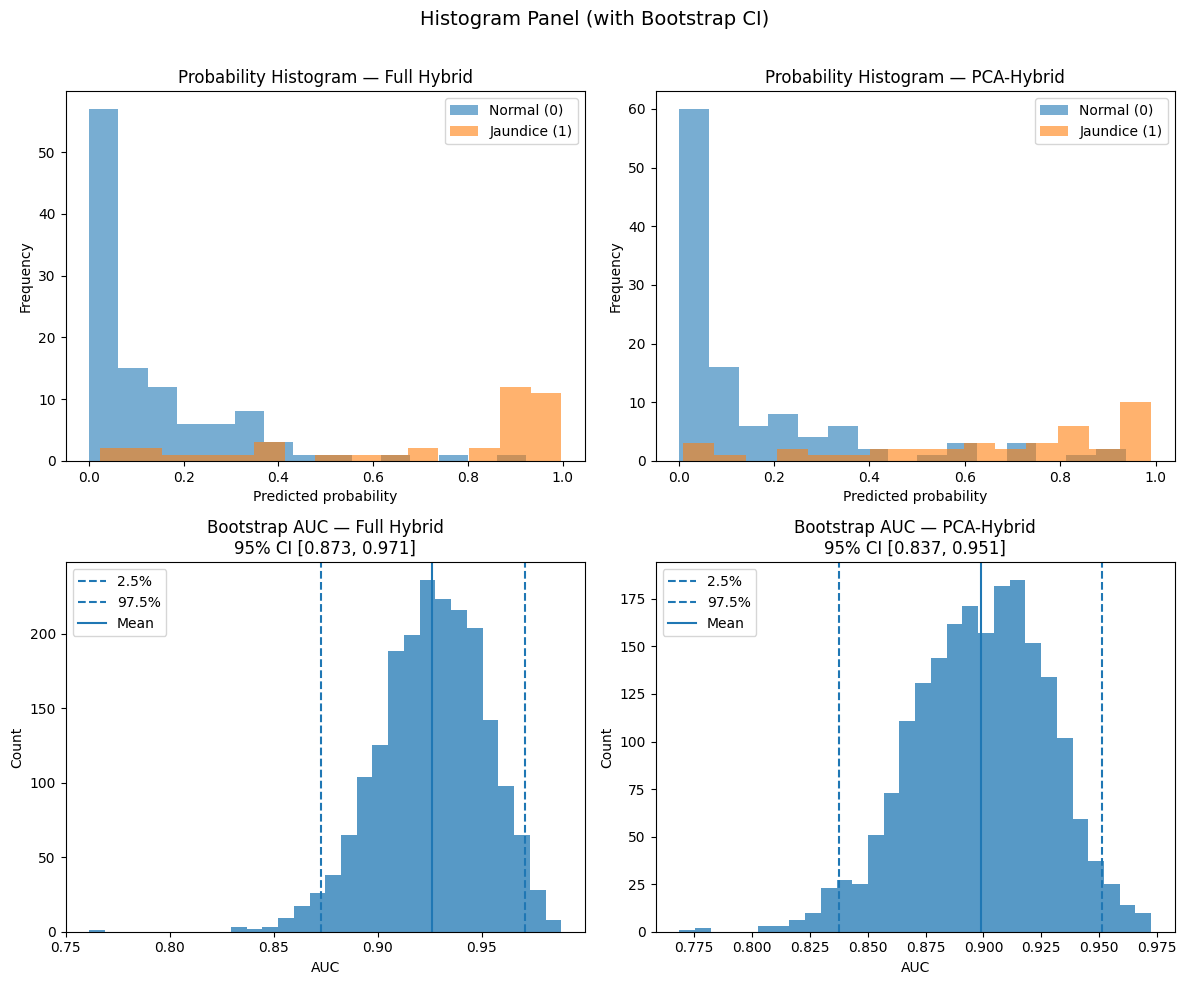

In [32]:
def plot_histogram_panel(res_full, res_pca):
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("Histogram Panel (with Bootstrap CI)", fontsize=14)

    probF = res_full["prob"]
    yF = res_full["y_true"]
    ax[0, 0].hist(probF[yF == 0], bins=15, alpha=0.6, label="Normal (0)")
    ax[0, 0].hist(probF[yF == 1], bins=15, alpha=0.6, label="Jaundice (1)")
    ax[0, 0].set_title("Probability Histogram — Full Hybrid")
    ax[0, 0].set_xlabel("Predicted probability")
    ax[0, 0].set_ylabel("Frequency")
    ax[0, 0].legend()

    probP = res_pca["prob"]
    yP = res_pca["y_true"]
    ax[0, 1].hist(probP[yP == 0], bins=15, alpha=0.6, label="Normal (0)")
    ax[0, 1].hist(probP[yP == 1], bins=15, alpha=0.6, label="Jaundice (1)")
    ax[0, 1].set_title("Probability Histogram — PCA-Hybrid")
    ax[0, 1].set_xlabel("Predicted probability")
    ax[0, 1].set_ylabel("Frequency")
    ax[0, 1].legend()

    ax[1, 0].hist(res_full["boot_auc"], bins=30, alpha=0.75)
    ax[1, 0].axvline(res_full["auc_ci_low"], linestyle="--", label="2.5%")
    ax[1, 0].axvline(res_full["auc_ci_high"], linestyle="--", label="97.5%")
    ax[1, 0].axvline(np.mean(res_full["boot_auc"]), label="Mean")
    ax[1, 0].set_title(
        f"Bootstrap AUC — Full Hybrid\n95% CI [{res_full['auc_ci_low']:.3f}, {res_full['auc_ci_high']:.3f}]"
    )
    ax[1, 0].set_xlabel("AUC")
    ax[1, 0].set_ylabel("Count")
    ax[1, 0].legend()

    ax[1, 1].hist(res_pca["boot_auc"], bins=30, alpha=0.75)
    ax[1, 1].axvline(res_pca["auc_ci_low"], linestyle="--", label="2.5%")
    ax[1, 1].axvline(res_pca["auc_ci_high"], linestyle="--", label="97.5%")
    ax[1, 1].axvline(np.mean(res_pca["boot_auc"]), label="Mean")
    ax[1, 1].set_title(
        f"Bootstrap AUC — PCA-Hybrid\n95% CI [{res_pca['auc_ci_low']:.3f}, {res_pca['auc_ci_high']:.3f}]"
    )
    ax[1, 1].set_xlabel("AUC")
    ax[1, 1].set_ylabel("Count")
    ax[1, 1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_histogram_panel(res_full, res_pca)

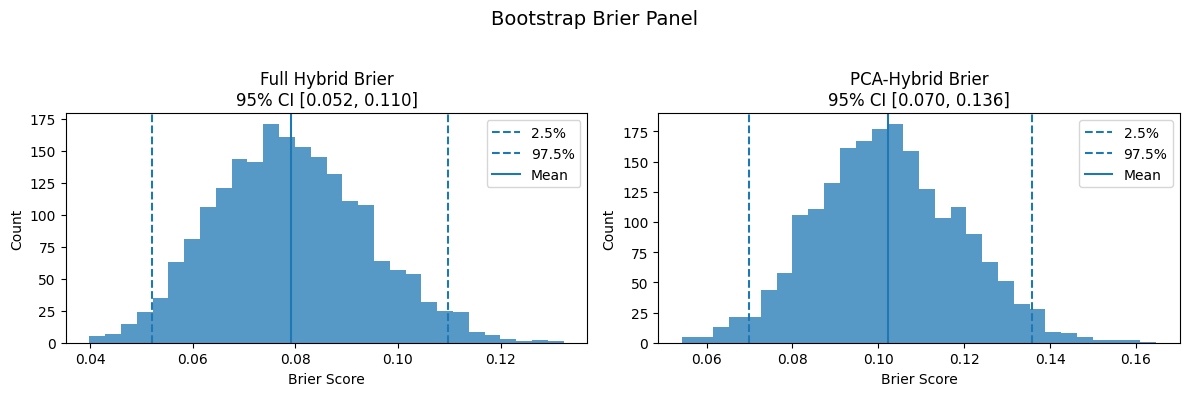

In [33]:
def plot_brier_hist_panel(res_full, res_pca):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Bootstrap Brier Panel", fontsize=14)

    ax[0].hist(res_full["boot_brier"], bins=30, alpha=0.75)
    ax[0].axvline(res_full["brier_ci_low"], linestyle="--", label="2.5%")
    ax[0].axvline(res_full["brier_ci_high"], linestyle="--", label="97.5%")
    ax[0].axvline(np.mean(res_full["boot_brier"]), label="Mean")
    ax[0].set_title(
        f"Full Hybrid Brier\n95% CI [{res_full['brier_ci_low']:.3f}, {res_full['brier_ci_high']:.3f}]"
    )
    ax[0].set_xlabel("Brier Score")
    ax[0].set_ylabel("Count")
    ax[0].legend()

    ax[1].hist(res_pca["boot_brier"], bins=30, alpha=0.75)
    ax[1].axvline(res_pca["brier_ci_low"], linestyle="--", label="2.5%")
    ax[1].axvline(res_pca["brier_ci_high"], linestyle="--", label="97.5%")
    ax[1].axvline(np.mean(res_pca["boot_brier"]), label="Mean")
    ax[1].set_title(
        f"PCA-Hybrid Brier\n95% CI [{res_pca['brier_ci_low']:.3f}, {res_pca['brier_ci_high']:.3f}]"
    )
    ax[1].set_xlabel("Brier Score")
    ax[1].set_ylabel("Count")
    ax[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_brier_hist_panel(res_full, res_pca)

In [34]:
def plot_threshold_curves(y_true, prob):
    ths = np.linspace(0.01, 0.99, 99)
    P, R, F1 = [], [], []

    for t in ths:
        pred = (prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1score = 2 * precision * recall / (precision + recall + 1e-9)

        P.append(precision)
        R.append(recall)
        F1.append(f1score)

    return ths, np.array(P), np.array(R), np.array(F1)

thsF, PF, RF, F1F = plot_threshold_curves(y_test, prob_full)
thsP, PP, RP, F1P = plot_threshold_curves(y_test, prob_pca)

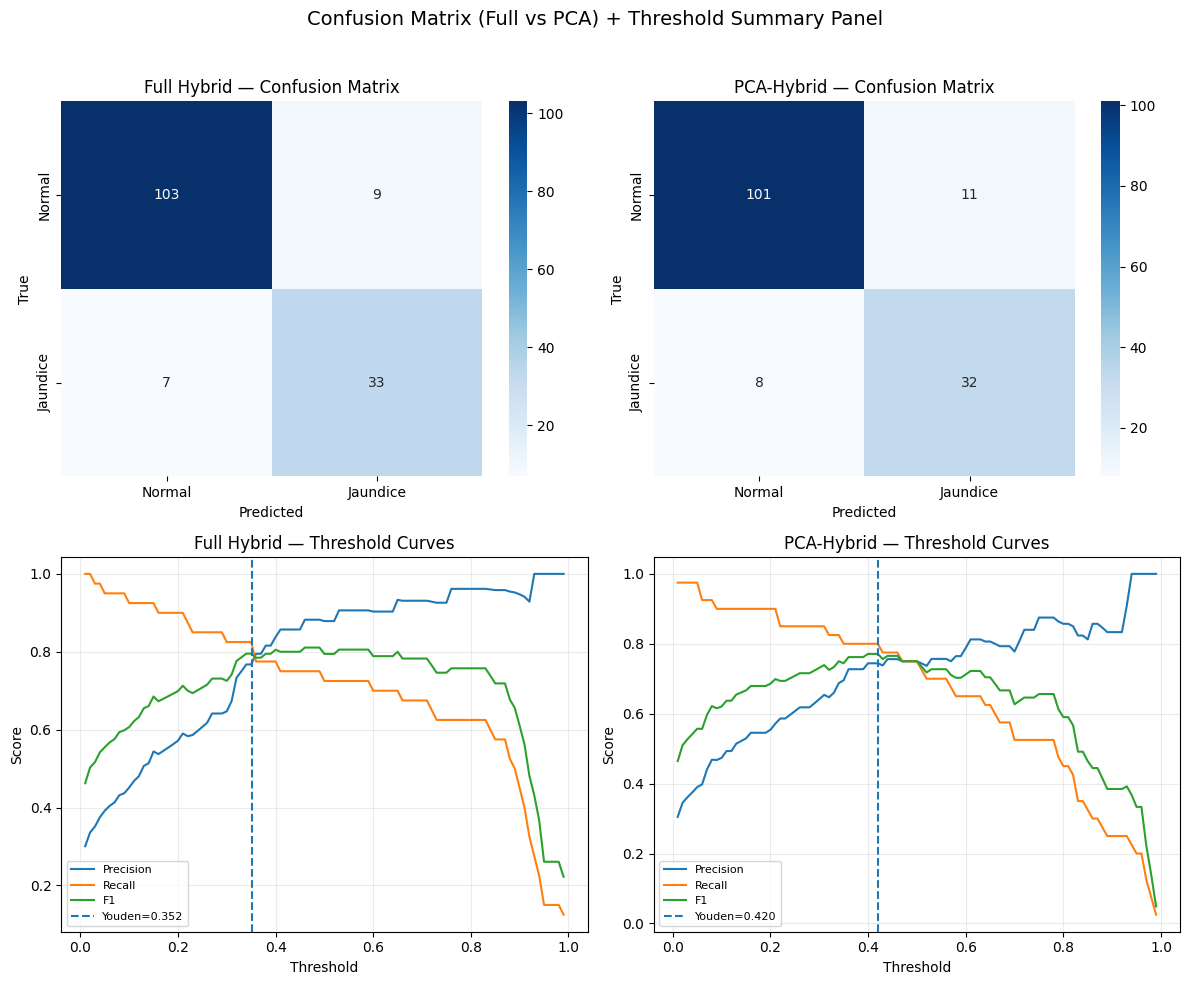

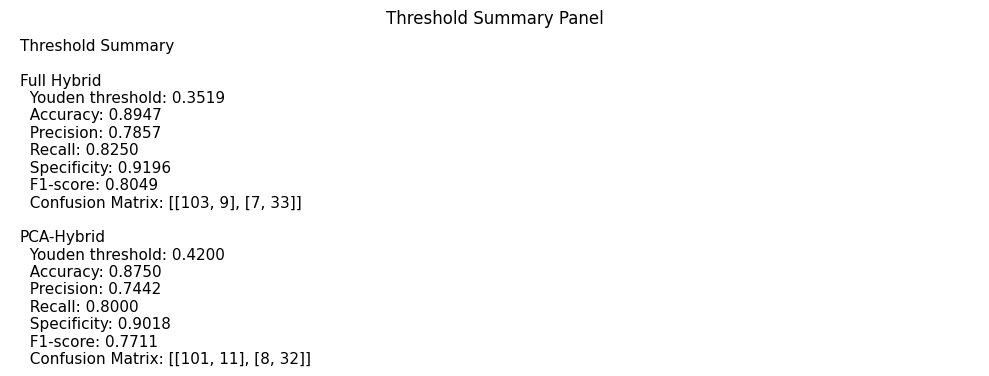

In [35]:
def plot_confusion_and_threshold_panel(res_full, res_pca):
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("Confusion Matrix (Full vs PCA) + Threshold Summary Panel", fontsize=14)

    sns.heatmap(
        np.array(res_full["cm"]),
        annot=True, fmt="d", cmap="Blues",
        xticklabels=["Normal", "Jaundice"], yticklabels=["Normal", "Jaundice"],
        ax=ax[0, 0]
    )
    ax[0, 0].set_title("Full Hybrid — Confusion Matrix")
    ax[0, 0].set_xlabel("Predicted")
    ax[0, 0].set_ylabel("True")

    sns.heatmap(
        np.array(res_pca["cm"]),
        annot=True, fmt="d", cmap="Blues",
        xticklabels=["Normal", "Jaundice"], yticklabels=["Normal", "Jaundice"],
        ax=ax[0, 1]
    )
    ax[0, 1].set_title("PCA-Hybrid — Confusion Matrix")
    ax[0, 1].set_xlabel("Predicted")
    ax[0, 1].set_ylabel("True")

    ax[1, 0].plot(thsF, PF, label="Precision")
    ax[1, 0].plot(thsF, RF, label="Recall")
    ax[1, 0].plot(thsF, F1F, label="F1")
    ax[1, 0].axvline(res_full["youden_thr"], linestyle="--", label=f"Youden={res_full['youden_thr']:.3f}")
    ax[1, 0].set_title("Full Hybrid — Threshold Curves")
    ax[1, 0].set_xlabel("Threshold")
    ax[1, 0].set_ylabel("Score")
    ax[1, 0].grid(alpha=0.25)
    ax[1, 0].legend(fontsize=8)

    ax[1, 1].plot(thsP, PP, label="Precision")
    ax[1, 1].plot(thsP, RP, label="Recall")
    ax[1, 1].plot(thsP, F1P, label="F1")
    ax[1, 1].axvline(res_pca["youden_thr"], linestyle="--", label=f"Youden={res_pca['youden_thr']:.3f}")
    ax[1, 1].set_title("PCA-Hybrid — Threshold Curves")
    ax[1, 1].set_xlabel("Threshold")
    ax[1, 1].set_ylabel("Score")
    ax[1, 1].grid(alpha=0.25)
    ax[1, 1].legend(fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.axis("off")

    summary_text = (
        "Threshold Summary\n\n"
        f"Full Hybrid\n"
        f"  Youden threshold: {res_full['youden_thr']:.4f}\n"
        f"  Accuracy: {res_full['acc']:.4f}\n"
        f"  Precision: {res_full['prec']:.4f}\n"
        f"  Recall: {res_full['rec']:.4f}\n"
        f"  Specificity: {res_full['spec']:.4f}\n"
        f"  F1-score: {res_full['f1']:.4f}\n"
        f"  Confusion Matrix: {res_full['cm']}\n\n"
        f"PCA-Hybrid\n"
        f"  Youden threshold: {res_pca['youden_thr']:.4f}\n"
        f"  Accuracy: {res_pca['acc']:.4f}\n"
        f"  Precision: {res_pca['prec']:.4f}\n"
        f"  Recall: {res_pca['rec']:.4f}\n"
        f"  Specificity: {res_pca['spec']:.4f}\n"
        f"  F1-score: {res_pca['f1']:.4f}\n"
        f"  Confusion Matrix: {res_pca['cm']}"
    )

    ax2.text(0.01, 0.98, summary_text, va="top", ha="left", fontsize=11)
    plt.title("Threshold Summary Panel")
    plt.tight_layout()
    plt.show()

plot_confusion_and_threshold_panel(res_full, res_pca)

## Statistical validation figure with all models annotated

Below, baseline model AUC values and confidence intervals are shown using the previously finalized frozen numbers.
The two proposed models are taken from the current V3 run.

In [36]:
frozen_models = pd.DataFrame([
    {"Model": "FH SVM", "AUC": 0.6929, "CI_low": 0.6028, "CI_high": 0.7745},
    {"Model": "CH SVM", "AUC": 0.7500, "CI_low": 0.6637, "CI_high": 0.8285},
    {"Model": "AB SVM", "AUC": 0.7558, "CI_low": 0.6652, "CI_high": 0.8414},
    {"Model": "Late Fusion (avg)", "AUC": 0.7913, "CI_low": 0.7167, "CI_high": 0.8594},
    {"Model": "Stacking (meta-learner)", "AUC": 0.7281, "CI_low": 0.6399, "CI_high": 0.8095},
    {"Model": "Classical Fusion", "AUC": 0.7842, "CI_low": 0.7060, "CI_high": 0.8538},
    {"Model": "PCA-Hybrid (160)", "AUC": res_pca["roc_auc"], "CI_low": res_pca["auc_ci_low"], "CI_high": res_pca["auc_ci_high"]},
    {"Model": "Hybrid Fusion (Final)", "AUC": res_full["roc_auc"], "CI_low": res_full["auc_ci_low"], "CI_high": res_full["auc_ci_high"]},
])

frozen_models

,Model,AUC,CI_low,CI_high
0,FH SVM,0.692900,0.602800,0.774500
1,CH SVM,0.750000,0.663700,0.828500
2,AB SVM,0.755800,0.665200,0.841400
3,Late Fusion (avg),0.791300,0.716700,0.859400
4,Stacking (meta-learner),0.728100,0.639900,0.809500
5,Classical Fusion,0.784200,0.706000,0.853800
6,PCA-Hybrid (160),0.899777,0.837374,0.951407
7,Hybrid Fusion (Final),0.926562,0.872915,0.970717


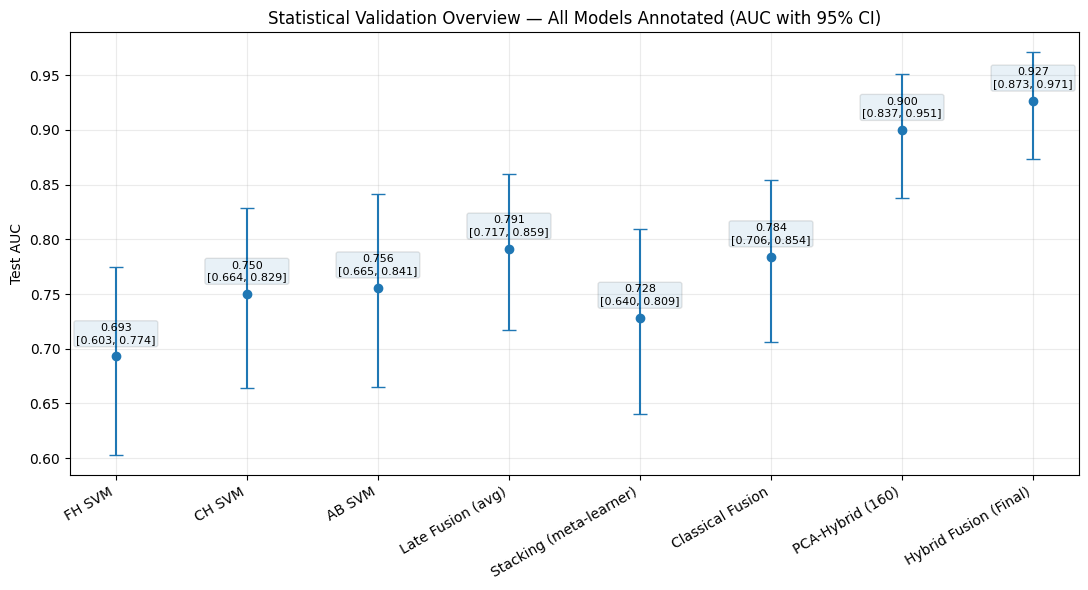

In [37]:
plt.figure(figsize=(11, 6))
x = np.arange(len(frozen_models))
auc_vals = frozen_models["AUC"].values
low_err = auc_vals - frozen_models["CI_low"].values
high_err = frozen_models["CI_high"].values - auc_vals

plt.errorbar(
    x, auc_vals,
    yerr=[low_err, high_err],
    fmt='o', capsize=5
)

for i, row in frozen_models.iterrows():
    plt.annotate(
        f"{row['AUC']:.3f}\n[{row['CI_low']:.3f}, {row['CI_high']:.3f}]",
        (i, row["AUC"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.20", alpha=0.10)
    )

plt.xticks(x, frozen_models["Model"], rotation=30, ha="right")
plt.ylabel("Test AUC")
plt.title("Statistical Validation Overview — All Models Annotated (AUC with 95% CI)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

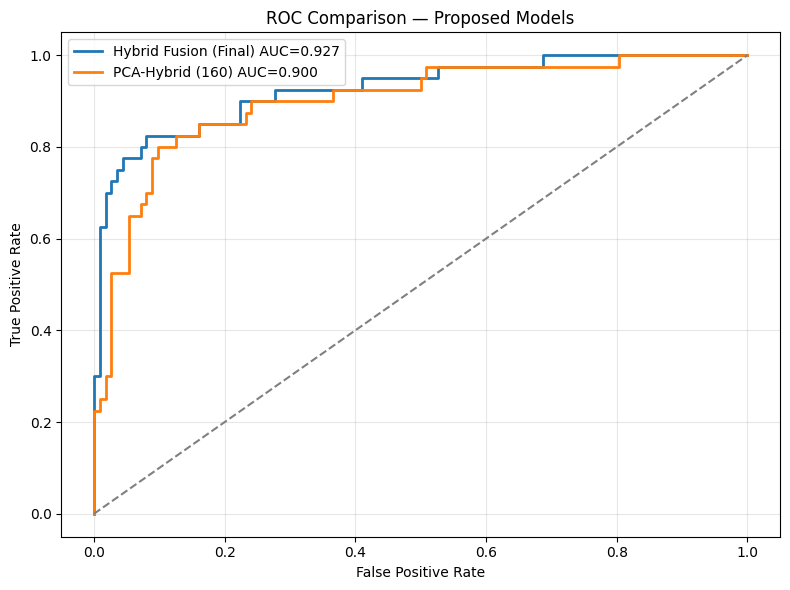

In [38]:
plt.figure(figsize=(8, 6))
plt.plot(res_full["fpr"], res_full["tpr"], linewidth=2, label=f"Hybrid Fusion (Final) AUC={res_full['roc_auc']:.3f}")
plt.plot(res_pca["fpr"], res_pca["tpr"], linewidth=2, label=f"PCA-Hybrid ({best_dim}) AUC={res_pca['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison — Proposed Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
comparison_df = pd.DataFrame([
    {
        "Model": "Hybrid Fusion (Final)",
        "Test AUC": round(res_full["roc_auc"], 4),
        "95% CI (AUC)": f'[{res_full["auc_ci_low"]:.4f}, {res_full["auc_ci_high"]:.4f}]',
        "PR AP": round(res_full["ap"], 4),
        "Brier Score": round(res_full["brier"], 4),
        "95% CI (Brier)": f'[{res_full["brier_ci_low"]:.4f}, {res_full["brier_ci_high"]:.4f}]',
        "Threshold": round(res_full["youden_thr"], 4),
        "Accuracy": round(res_full["acc"], 4),
        "Precision": round(res_full["prec"], 4),
        "Recall": round(res_full["rec"], 4),
        "Specificity": round(res_full["spec"], 4),
        "F1-score": round(res_full["f1"], 4),
        "Confusion Matrix": str(res_full["cm"])
    },
    {
        "Model": f"PCA-Hybrid ({best_dim})",
        "Test AUC": round(res_pca["roc_auc"], 4),
        "95% CI (AUC)": f'[{res_pca["auc_ci_low"]:.4f}, {res_pca["auc_ci_high"]:.4f}]',
        "PR AP": round(res_pca["ap"], 4),
        "Brier Score": round(res_pca["brier"], 4),
        "95% CI (Brier)": f'[{res_pca["brier_ci_low"]:.4f}, {res_pca["brier_ci_high"]:.4f}]',
        "Threshold": round(res_pca["youden_thr"], 4),
        "Accuracy": round(res_pca["acc"], 4),
        "Precision": round(res_pca["prec"], 4),
        "Recall": round(res_pca["rec"], 4),
        "Specificity": round(res_pca["spec"], 4),
        "F1-score": round(res_pca["f1"], 4),
        "Confusion Matrix": str(res_pca["cm"])
    }
])

comparison_df

,Model,Test AUC,95% CI (AUC),PR AP,Brier Score,95% CI (Brier),Threshold,Accuracy,Precision,Recall,Specificity,F1-score,Confusion Matrix
0,Hybrid Fusion (Final),0.9266,"[0.8729, 0.9707]",0.8729,0.0790,"[0.0520, 0.1097]",0.3519,0.8947,0.7857,0.825,0.9196,0.8049,"[[103, 9], [7, 33]]"
1,PCA-Hybrid (160),0.8998,"[0.8374, 0.9514]",0.7963,0.1018,"[0.0700, 0.1358]",0.4200,0.8750,0.7442,0.800,0.9018,0.7711,"[[101, 11], [8, 32]]"


In [40]:
print("===== Hybrid Fusion (Final) — Table 1 =====")
print(f"Test AUC: {res_full['roc_auc']:.4f}")
print(f"95% CI (AUC): [{res_full['auc_ci_low']:.4f}, {res_full['auc_ci_high']:.4f}]")
print(f"PR AP: {res_full['ap']:.4f}")
print(f"Brier score: {res_full['brier']:.4f}")
print(f"95% CI (Brier): [{res_full['brier_ci_low']:.4f}, {res_full['brier_ci_high']:.4f}]")

print("\n===== Hybrid Fusion (Final) — Table 2 (Youden J) =====")
print("Threshold rule: Youden J")
print(f"Threshold: {res_full['youden_thr']:.4f}")
print(f"Accuracy: {res_full['acc']:.4f}")
print(f"Precision: {res_full['prec']:.4f}")
print(f"Recall: {res_full['rec']:.4f}")
print(f"Specificity: {res_full['spec']:.4f}")
print(f"F1-score: {res_full['f1']:.4f}")
print(f"Confusion matrix: {res_full['cm']}")

print("\n===== PCA-Hybrid — Table 1 =====")
print(f"Test AUC: {res_pca['roc_auc']:.4f}")
print(f"95% CI (AUC): [{res_pca['auc_ci_low']:.4f}, {res_pca['auc_ci_high']:.4f}]")
print(f"PR AP: {res_pca['ap']:.4f}")
print(f"Brier score: {res_pca['brier']:.4f}")
print(f"95% CI (Brier): [{res_pca['brier_ci_low']:.4f}, {res_pca['brier_ci_high']:.4f}]")

print("\n===== PCA-Hybrid — Table 2 (Youden J) =====")
print("Threshold rule: Youden J")
print(f"Threshold: {res_pca['youden_thr']:.4f}")
print(f"Accuracy: {res_pca['acc']:.4f}")
print(f"Precision: {res_pca['prec']:.4f}")
print(f"Recall: {res_pca['rec']:.4f}")
print(f"Specificity: {res_pca['spec']:.4f}")
print(f"F1-score: {res_pca['f1']:.4f}")
print(f"Confusion matrix: {res_pca['cm']}")

===== Hybrid Fusion (Final) — Table 1 =====
Test AUC: 0.9266
95% CI (AUC): [0.8729, 0.9707]
PR AP: 0.8729
Brier score: 0.0790
95% CI (Brier): [0.0520, 0.1097]

===== Hybrid Fusion (Final) — Table 2 (Youden J) =====
Threshold rule: Youden J
Threshold: 0.3519
Accuracy: 0.8947
Precision: 0.7857
Recall: 0.8250
Specificity: 0.9196
F1-score: 0.8049
Confusion matrix: [[103, 9], [7, 33]]

===== PCA-Hybrid — Table 1 =====
Test AUC: 0.8998
95% CI (AUC): [0.8374, 0.9514]
PR AP: 0.7963
Brier score: 0.1018
95% CI (Brier): [0.0700, 0.1358]

===== PCA-Hybrid — Table 2 (Youden J) =====
Threshold rule: Youden J
Threshold: 0.4200
Accuracy: 0.8750
Precision: 0.7442
Recall: 0.8000
Specificity: 0.9018
F1-score: 0.7711
Confusion matrix: [[101, 11], [8, 32]]


In [41]:
comparison_df.to_csv("effnet_full_vs_pcahybrid_v3_summary.csv", index=False)
sweep_df.to_csv("effnet_v3_pca_sweep_results.csv", index=False)
frozen_models.to_csv("effnet_v3_all_model_auc_ci_overview.csv", index=False)

print("Saved: effnet_full_vs_pcahybrid_v3_summary.csv")
print("Saved: effnet_v3_pca_sweep_results.csv")
print("Saved: effnet_v3_all_model_auc_ci_overview.csv")

Saved: effnet_full_vs_pcahybrid_v3_summary.csv
Saved: effnet_v3_pca_sweep_results.csv
Saved: effnet_v3_all_model_auc_ci_overview.csv


## Development / deployment export

This saves:
- imputer
- PCA model
- SVM full
- SVM PCA
- model metadata
- feature column order

For future deployment, the PCA-Hybrid model is the preferred lightweight option.

In [42]:
# ── SAVE PATH (Drive এ) ──────────────────────────────────────
SAVE_PATH = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/"
import os
os.makedirs(SAVE_PATH, exist_ok=True)

bundle = {
    "classical_feature_columns": classical_cols,
    "imputer": imputer,
    "pca_dim": int(best_dim),
    "pca_model": pca,
    "svm_full": svm_full,
    "svm_pca": svm_pca,
    "roi_config": {
        "classical_forehead": "dynamic tight heuristic",
        "classical_chest":   {"x1": 0.28, "x2": 0.78, "y1": 0.50, "y2": 0.72},
        "classical_abdomen": {"x1": 0.25, "x2": 0.75, "y1": 0.60, "y2": 0.92},
        "deep_forehead":     {"x1": 0.25, "x2": 0.75, "y1": 0.10, "y2": 0.40},
        "deep_chest":        {"x1": 0.25, "x2": 0.75, "y1": 0.40, "y2": 0.80},
        "deep_abdomen":      {"x1": 0.25, "x2": 0.75, "y1": 0.55, "y2": 0.92},
    },
    "model_names": {
        "full": "Hybrid Fusion (Final)",
        "pca":  f"PCA-Hybrid ({best_dim})"
    },
    "results_full": res_full,
    "results_pca":  res_pca
}

BUNDLE_PATH = SAVE_PATH + "NJN_EffNet_Full_vs_PCAHybrid_V3_bundle.joblib"
joblib.dump(bundle, BUNDLE_PATH)
print(f"✅ Bundle saved to Drive: {BUNDLE_PATH}")

✅ Bundle saved to Drive: /content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN_EffNet_Full_vs_PCAHybrid_V3_bundle.joblib


In [43]:
KERAS_PATH = SAVE_PATH + "NJN_EffNetB0_feature_extractor_V3.keras"
eff.save(KERAS_PATH)
print(f"✅ EfficientNetB0 saved to Drive: {KERAS_PATH}")

✅ EfficientNetB0 saved to Drive: /content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN_EffNetB0_feature_extractor_V3.keras


In [44]:
def build_classical_row_from_image(img_bgr):
    fh = extract_forehead_roi_classical(img_bgr)
    ch = extract_chest_roi_classical(img_bgr)
    ab = extract_abdomen_roi_classical(img_bgr)

    if fh is None or ch is None or ab is None:
        return None

    fh_feat = extract_classical_features(fh)
    ch_feat = extract_classical_features(ch)
    ab_feat = extract_classical_features(ab)

    row = {}
    row.update({f"FH_{k}": v for k, v in fh_feat.items()})
    row.update({f"CH_{k}": v for k, v in ch_feat.items()})
    row.update({f"AB_{k}": v for k, v in ab_feat.items()})
    return row


def predict_single_image(image_path, mode="pca"):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not read image.")

    row = build_classical_row_from_image(img)
    if row is None:
        raise ValueError("Classical ROI extraction failed.")

    x_classical_df = pd.DataFrame([row])[classical_cols]
    x_classical    = imputer.transform(x_classical_df)

    e_fh = get_eff_embedding(img, extract_forehead_roi_deep)
    e_ch = get_eff_embedding(img, extract_chest_roi_deep)
    e_ab = get_eff_embedding(img, extract_abdomen_roi_deep)

    if (e_fh is None) or (e_ch is None) or (e_ab is None):
        raise ValueError("Deep embedding extraction failed.")

    deep = np.hstack([e_fh, e_ch, e_ab]).reshape(1, -1)

    if mode == "full":
        X         = np.hstack([x_classical, deep])
        prob      = svm_full.predict_proba(X)[:, 1][0]
        threshold = res_full["youden_thr"]
        model_name = "Hybrid Fusion (Final)"
    else:
        deep_pca_1 = pca.transform(deep)
        X          = np.hstack([x_classical, deep_pca_1])
        prob       = svm_pca.predict_proba(X)[:, 1][0]
        threshold  = res_pca["youden_thr"]
        model_name = f"PCA-Hybrid ({best_dim})"

    pred = int(prob >= threshold)

    return {
        "model":                  model_name,
        "threshold":              float(threshold),
        "probability_jaundice":   float(prob),
        "predicted_label":        int(pred),
        "predicted_class_name":   "Jaundice" if pred == 1 else "Normal"
    }

In [45]:
# Quick single-image smoke test
test_result_full = predict_single_image(imgs[0], mode="full")
test_result_pca  = predict_single_image(imgs[0], mode="pca")

print("Full model result:", test_result_full)
print("PCA  model result:", test_result_pca)

Full model result: {'model': 'Hybrid Fusion (Final)', 'threshold': 0.35191261584731887, 'probability_jaundice': 0.007568663575384743, 'predicted_label': 0, 'predicted_class_name': 'Normal'}
PCA  model result: {'model': 'PCA-Hybrid (160)', 'threshold': 0.4200273849174287, 'probability_jaundice': 0.027171704656439644, 'predicted_label': 0, 'predicted_class_name': 'Normal'}


In [46]:
deployment_meta = {
    "preferred_deployment_model":      f"PCA-Hybrid ({best_dim})",
    "reason":                          "lightweight proposed model for future real-time deployment",
    "best_pca_dim":                    int(best_dim),
    "classical_feature_count":         int(len(classical_cols)),
    "deep_embedding_dim_before_pca":   int(deep_train.shape[1]),
    "deep_embedding_dim_after_pca":    int(best_dim),
    "full_model_threshold_youden":     float(res_full["youden_thr"]),
    "pca_model_threshold_youden":      float(res_pca["youden_thr"]),
    "full_model_auc":                  float(res_full["roc_auc"]),
    "pca_model_auc":                   float(res_pca["roc_auc"])
}

META_PATH = SAVE_PATH + "NJN_EffNet_Full_vs_PCAHybrid_V3_deployment_meta.json"
with open(META_PATH, "w") as f:
    json.dump(deployment_meta, f, indent=2)

print(f"✅ Deployment meta saved to Drive: {META_PATH}")
print(deployment_meta)

✅ Deployment meta saved to Drive: /content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN_EffNet_Full_vs_PCAHybrid_V3_deployment_meta.json
{'preferred_deployment_model': 'PCA-Hybrid (160)', 'reason': 'lightweight proposed model for future real-time deployment', 'best_pca_dim': 160, 'classical_feature_count': 81, 'deep_embedding_dim_before_pca': 3840, 'deep_embedding_dim_after_pca': 160, 'full_model_threshold_youden': 0.35191261584731887, 'pca_model_threshold_youden': 0.4200273849174287, 'full_model_auc': 0.9265625, 'pca_model_auc': 0.8997767857142858}


In [47]:
comparison_df.to_csv(
    SAVE_PATH + "effnet_full_vs_pcahybrid_v3_summary.csv", index=False)
sweep_df.to_csv(
    SAVE_PATH + "effnet_v3_pca_sweep_results.csv", index=False)
frozen_models.to_csv(
    SAVE_PATH + "effnet_v3_all_model_auc_ci_overview.csv", index=False)

print("✅ All CSVs saved to Drive")
print(f"   → {SAVE_PATH}effnet_full_vs_pcahybrid_v3_summary.csv")
print(f"   → {SAVE_PATH}effnet_v3_pca_sweep_results.csv")
print(f"   → {SAVE_PATH}effnet_v3_all_model_auc_ci_overview.csv")

✅ All CSVs saved to Drive
   → /content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/effnet_full_vs_pcahybrid_v3_summary.csv
   → /content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/effnet_v3_pca_sweep_results.csv
   → /content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/effnet_v3_all_model_auc_ci_overview.csv


## End of notebook

After running this notebook, you will have:
- final proposed-model comparison
- exact 95% CI for AUC
- exact 95% CI for Brier
- side-by-side panels
- all-model AUC+CI validation figure
- exported development bundle

For future React Native deployment, use the exported **PCA-Hybrid** bundle as the lightweight option.

***Thank you. by A. Sayem***

**Non-Invasive Neonatal Jaundice Detection from Multi-Region Skin Images Using Calibrated Hybrid Deep–Biomarker Fusion**

**A Calibrated Multi-Region Hybrid Framework for Neonatal Jaundice Detection from Skin Images**

**Calibrated Hybrid Fusion of Multi-Region Skin Biomarkers and Deep Embeddings for Non-Invasive Neonatal Jaundice Detection**

Multi-Region Hybrid Fusion with Probabilistic Calibration for Neonatal Jaundice Screening